In [7]:
import numpy as np
import scipy.signal as signal
import scanpy as sc


In [2]:

def detect_peaks(spectra, prominence=0.01):
    """Detect peaks using prominence thresholding."""
    peaks, properties = signal.find_peaks(spectra, prominence=prominence)
    return peaks, properties["prominences"]

def process_maldi_data(adata, prominence=0.01, output_file="processed_data.h5ad"):
    """Peak detection pipeline for AnnData."""
    processed_data = []
    
    for i in range(adata.shape[0]):  # Iterate over spectra (rows)
        spectrum = adata.X[i].toarray().flatten()  # Convert to dense array if sparse
        peaks, _ = detect_peaks(spectrum, prominence=prominence)
        
        processed_spectrum = np.zeros_like(spectrum)
        processed_spectrum[peaks] = spectrum[peaks]  # Keep only the peaks
        processed_data.append(processed_spectrum)
    
    adata.layers["processed"] = np.array(processed_data)
    
    # Save the processed AnnData object
    adata.write(output_file)
    print(f"Processed data saved to: {output_file}")

    return adata

In [3]:
# Define the file paths
input_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad"
output_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_processed.h5ad"

# Load the existing AnnData object
adata = sc.read_h5ad(input_file)
print(f"Loaded AnnData from: {input_file}")

# Run peak detection and save it
adata = process_maldi_data(adata, output_file=output_file)

print(f"Processed data saved to: {output_file}")

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Loaded AnnData from: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad
Processed data saved to: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_processed.h5ad
Processed data saved to: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_processed.h5ad


In [12]:
import numpy as np
import scipy.signal as signal
import scanpy as sc
from tqdm import tqdm


In [13]:
def detect_peaks(spectrum, mz_axis, prominence=0.01):
    """Detect peaks with prominence and return m/z and intensity."""
    peaks, properties = signal.find_peaks(spectrum, prominence=prominence)
    return mz_axis[peaks], spectrum[peaks]

def ppm_diff(ref_mz, target_mz):
    return (target_mz - ref_mz) / ref_mz * 1e6

def find_top_peaks_global(adata, prominence=0.01, n_peaks=100, ppm_tolerance=10):
    all_peaks = []

    # Use var_names (index) as the m/z axis
    mz_axis = adata.var_names.astype(float).values

    for i in tqdm(range(adata.shape[0]), desc="Detecting peaks"):
        spectrum = adata.X[i].toarray().flatten()
        mz_peaks, intensities = detect_peaks(spectrum, mz_axis, prominence)
        all_peaks.extend(list(zip(mz_peaks, intensities)))

    # Convert to structured array and sort by intensity
    all_peaks = np.array(all_peaks, dtype=[("mz", float), ("intensity", float)])
    sorted_peaks = np.sort(all_peaks, order="intensity")[::-1]

    # Select top N, removing duplicates within ±ppm_tolerance
    selected_peaks = []
    for peak in sorted_peaks:
        if len(selected_peaks) >= n_peaks:
            break
        if all(abs(ppm_diff(p["mz"], peak["mz"])) > ppm_tolerance for p in selected_peaks):
            selected_peaks.append(peak)

    return np.sort(np.array([p["mz"] for p in selected_peaks]))

    return np.sort(np.array([p["mz"] for p in selected_peaks]))

def wwextract_selected_peaks(adata, selected_mz, ppm_tolerance=10):
    mz_axis = adata.var["mz"].values
    selected_indices = []

    for target_mz in selected_mz:
        # Find index closest to target_mz within tolerance
        diffs = ppm_diff(target_mz, mz_axis)
        candidates = np.where(np.abs(diffs) <= ppm_tolerance)[0]
        if candidates.size > 0:
            selected_indices.append(candidates[np.argmin(np.abs(diffs[candidates]))])

    selected_indices = sorted(set(selected_indices))

    # Create new AnnData with filtered m/z
    from scipy import sparse
    new_X = adata.X[:, selected_indices]
    new_var = adata.var.iloc[selected_indices].copy()

    new_adata = sc.AnnData(X=new_X, obs=adata.obs.copy(), var=new_var)
    return new_adata
def extract_selected_peaks(adata, selected_mz, ppm_tolerance=10):
    mz_axis = adata.var_names.astype(float).values
    selected_indices = []

    for target_mz in selected_mz:
        # Find index closest to target_mz within tolerance
        ppm_diff_array = np.abs((mz_axis - target_mz) / target_mz * 1e6)
        idx = np.argmin(ppm_diff_array)
        if ppm_diff_array[idx] <= ppm_tolerance:
            selected_indices.append(idx)

    # Sort indices and extract subset
    selected_indices = np.sort(selected_indices)
    new_adata = adata[:, selected_indices].copy()
    return new_adata

In [14]:
# File paths
input_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad"
output_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_topN_ppm.h5ad"

# Parameters
prominence = 0.01
top_n = 100
ppm_tolerance = 10

# Load and process
adata = sc.read_h5ad(input_file)
print(f"Loaded AnnData from: {input_file}")

selected_mz = find_top_peaks_global(adata, prominence=prominence, n_peaks=top_n, ppm_tolerance=ppm_tolerance)
adata_top_peaks = extract_selected_peaks(adata, selected_mz, ppm_tolerance=ppm_tolerance)

# Save the reduced AnnData
adata_top_peaks.write(output_file)
print(f"Reduced AnnData with top {top_n} peaks saved to: {output_file}")

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Loaded AnnData from: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad


Detecting peaks: 100%|███████████████████| 16605/16605 [01:47<00:00, 153.93it/s]


Reduced AnnData with top 100 peaks saved to: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_topN_ppm.h5ad


In [8]:
input_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad"
adata = sc.read_h5ad(input_file)
print(adata.var.head())

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


                         mzs
49.95323181152344  49.953232
49.95631790161133  49.956318
49.95940399169922  49.959404
49.96249008178711  49.962490
49.965576171875    49.965576


In [15]:
input_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_topN_ppm.h5ad"
adata = sc.read_h5ad(input_file)

In [16]:
print(adata)

AnnData object with n_obs × n_vars = 16605 × 100
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'tic_normalized'


In [17]:
adata.var

,mzs
112.89804077148438,112.898041
137.02508544921875,137.025085
175.9821319580078,175.982132
184.072021484375,184.072021
192.9800567626953,192.980057
...,...
798.5390625,798.539062
798.5513916015625,798.551392
799.538818359375,799.538818
799.5511474609375,799.551147


In [18]:
adata.X

<16605x100 sparse matrix of type '<class 'numpy.float64'>'
	with 1467794 stored elements in Compressed Sparse Row format>

In [19]:
import matplotlib.pyplot as plt

def plot_top_peaks_spatial(adata, mz_values, n_cols=5, figsize=(15, 8)):
    coords = adata.obs[["x", "y"]].values
    n_rows = int(np.ceil(len(mz_values) / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    axs = axs.flatten()

    for i, (mz, ax) in enumerate(zip(mz_values, axs)):
        intensity = adata.X[:, i].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, i]
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=intensity, cmap="viridis", s=5)
        ax.set_title(f"m/z: {mz:.4f}")
        ax.axis("off")
        fig.colorbar(sc, ax=ax, shrink=0.6)

    # Hide unused axes
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()


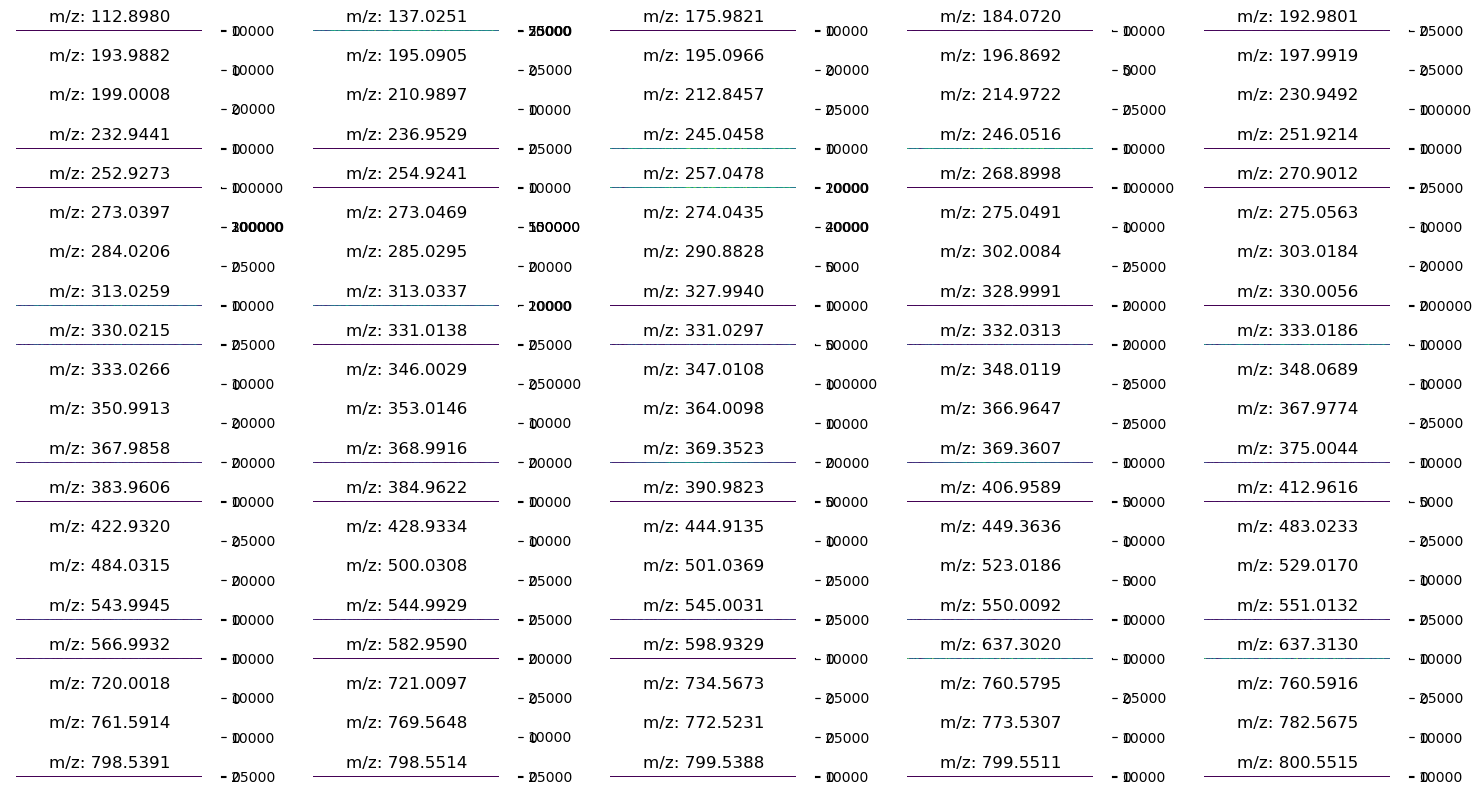

In [20]:
plot_top_peaks_spatial(adata_top_peaks, selected_mz)


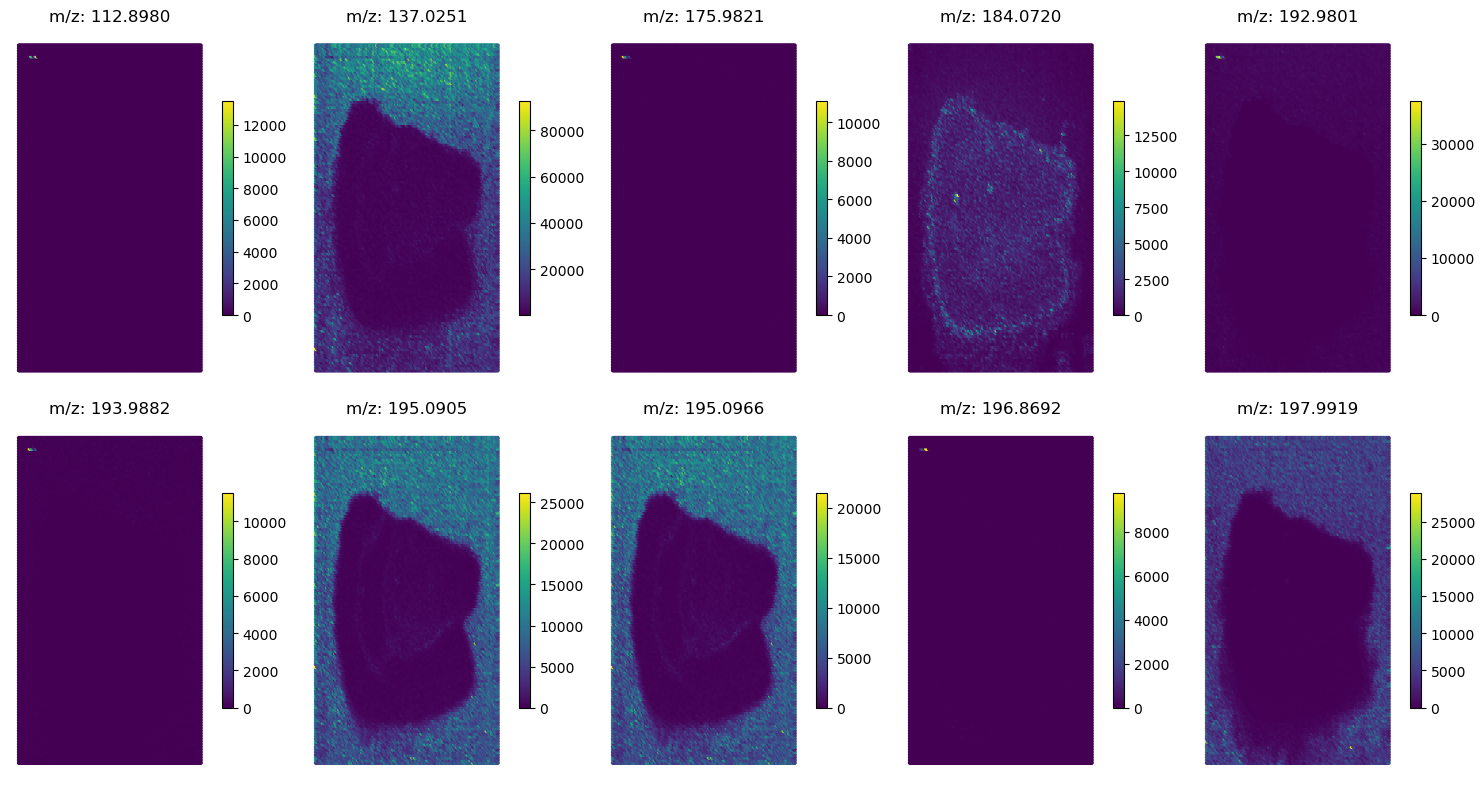

In [21]:
plot_top_peaks_spatial(adata_top_peaks[:, :10], selected_mz[:10])

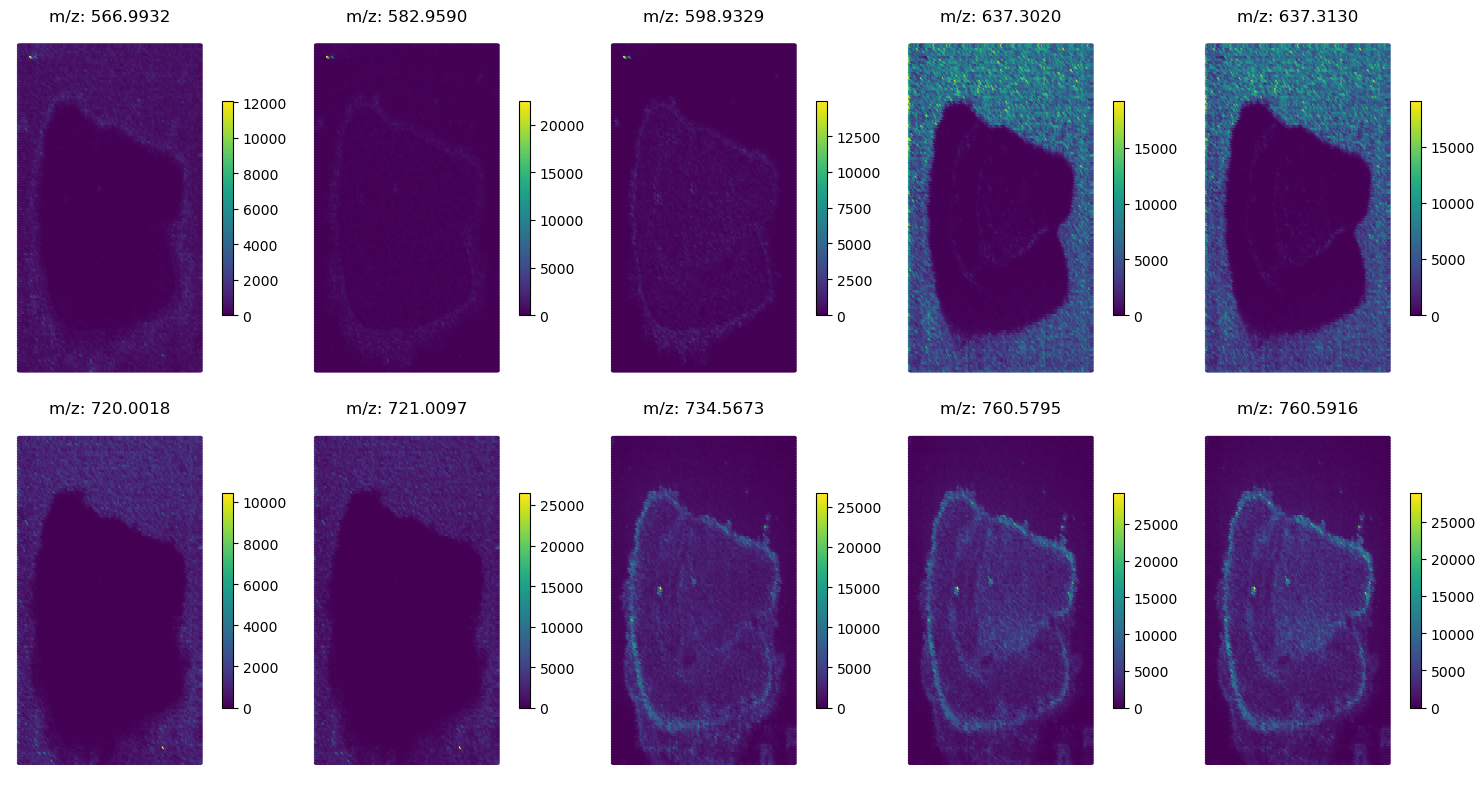

In [23]:
plot_top_peaks_spatial(adata_top_peaks[:,80:90], selected_mz[80:90])

In [24]:
def plot_spectrum_pixel(adata, pixel_index):
    import matplotlib.pyplot as plt

    # Convert var_names (m/z values) to float
    mz_axis = adata.var_names.astype(float).values
    # Get the spectrum
    spectrum = adata.X[pixel_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[pixel_index]

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(mz_axis, spectrum, lw=1)
    plt.xlabel("m/z")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum at pixel index {pixel_index}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

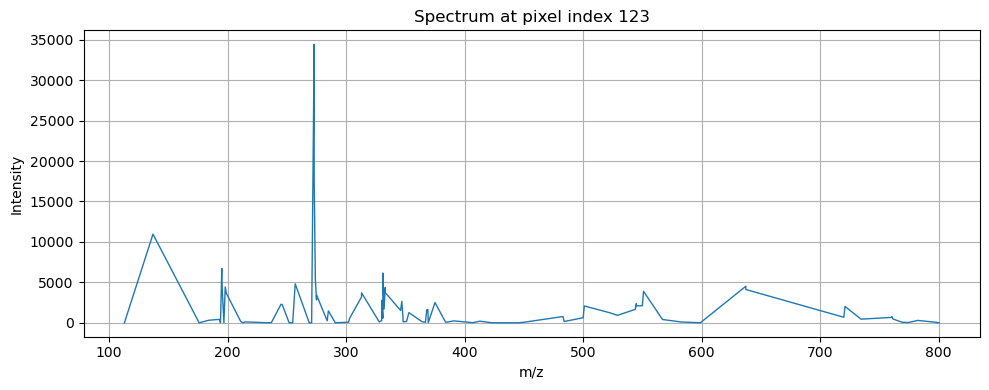

In [25]:
plot_spectrum_pixel(adata, pixel_index=123)  # Replace 123 with any index you want


In [26]:
def stem_plot_spectrum_pixel(adata, pixel_index):
    import matplotlib.pyplot as plt

    # Get m/z values and intensity at given pixel
    mz_axis = adata.var_names.astype(float).values
    spectrum = adata.X[pixel_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[pixel_index]

    # Plot stem
    plt.figure(figsize=(12, 4))
    markerline, stemlines, baseline = plt.stem(mz_axis, spectrum, linefmt='C0-', markerfmt='C0o', basefmt=" ")
    plt.setp(markerline, markersize=3)
    plt.xlabel("m/z")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum at pixel index {pixel_index} (Stem Plot)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

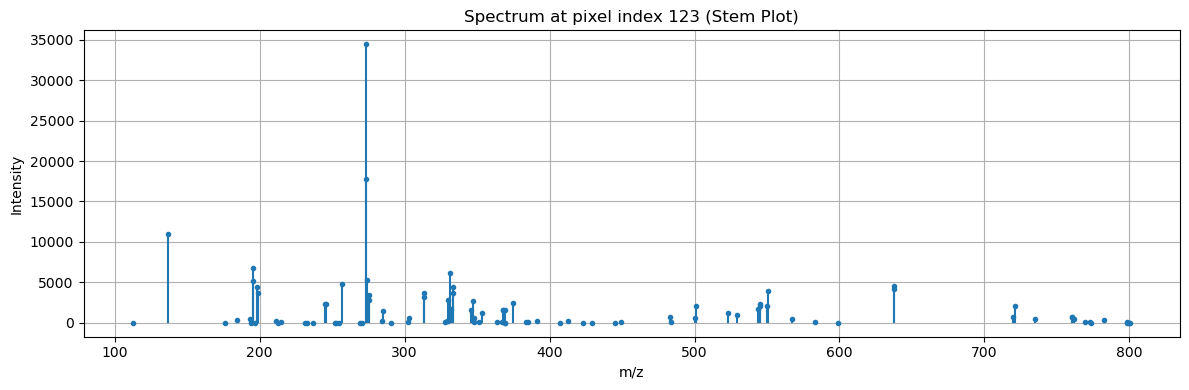

In [27]:
stem_plot_spectrum_pixel(adata, pixel_index=123)
